# Best neighborhood in Pittsburgh for your family

***By Matthew and Arif***

In [137]:
from IPython.display import Image, display

url = "https://images.squarespace-cdn.com/content/v1/54bd63f8e4b0ac034b30994b/1647531288867-SPYCBL640BIFAMZI4W12/Pittsburgh-Wedding-Photographer-Pittsburgh-Senior-Photographer_2901.jpg"

display(Image(url=url))

Metrics that we will use to determine the best neighborhood in Pittsburgh are: ***Criminal activity and safety***(Arrest numbers per nieghborhood), ***Housing Violations***(PLI/ES/DOMI Violations), and ***Condemned and Dead-end Properties***(Number of condemned or dead-end properties per neighborhood)

# Metric #1: Criminal activity and safety

***By Matthew and Arif***

In [138]:
from IPython.display import Image, display

url = "https://i.etsystatic.com/27443220/r/il/a24eba/3255584618/il_fullxfull.3255584618_i5po.jpg"

display(Image(url=url))

Public saftey often starts with law enforcement. A given data of arrest reports are shown in order to uphold which neighborhood has the least amount of crime and more importantly the least dangerous kind of crime.

In [139]:
#imports panda library
import pandas as pd

url = "https://data.wprdc.org/datastore/dump/e419c20c-8df4-4729-830c-e49427a656e0"

#contains arrest data
df = pd.read_csv(url)
df.head()

,_id,Template,Case_Number,ArrestPerson_ID,Arrest_Date,Arrest_Year,Arrest_Month,Arrest_Time,Type,ArrestPerson_Age,...,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,Zone,Tract,Neighborhood,ArrestCharge_Felony_Misdemeanor_Description,XCOORD,YCOORD,Block_Address
0,1,Adult Arrest-On View,PGHP26028801,a50bb4e9-1417-c449-66ab-08de7753d503,2026-02-28,2026.0,Feb,22:54,On-View Arrest (apprehension without a warrant...,25.0,...,Person,A,18 2718 A1 Strangulation Basic - Applying,Zone 4,1504.0,Glen Hazel,MISDEMEANOR - M2,-79.9332,40.4054,"700 BLOCK OF JOHNSTON AVE PITTSBURGH, PA"
1,2,Adult Arrest-On View,PGHP26028801,a50bb4e9-1417-c449-66ab-08de7753d503,2026-02-28,2026.0,Feb,22:54,On-View Arrest (apprehension without a warrant...,25.0,...,Person,A,18 2701 A1 Simple Assault-General,Zone 4,1504.0,Glen Hazel,MISDEMEANOR - M2,-79.9332,40.4054,"700 BLOCK OF JOHNSTON AVE PITTSBURGH, PA"
2,3,Adult Arrest-302,PGHP26028803,fe3728d9-7382-c593-4319-08de77516c71,2026-02-28,2026.0,Feb,22:32,Taken Into Custody (based on a warrant and/or ...,32.0,...,Group B,B,302 302 Warrant,Zone 1,2615.0,Perry South,NaN,-80.0078,40.4718,"2600 BLOCK OF MAPLE AVE, PITTSBURGH 15214 PITT..."
3,4,Juvenile Arrest - 302,PGHP26028828,a480b72c-43fb-c021-c415-08de77572633,2026-02-28,2026.0,Feb,23:17,Taken Into Custody (based on a warrant and/or ...,13.0,...,Group B,B,302 302 Warrant,Zone 3,2902.0,Carrick,NaN,-79.9831,40.4012,"1500 BLOCK OF TRANSVERSE PITTSBURGH, PA"
4,5,Adult Arrest-On View,PGHP26028804,5dd0ef50-ace6-c129-2bc1-08de7758642a,2026-02-28,2026.0,Feb,22:27,On-View Arrest (apprehension without a warrant...,23.0,...,Person,A,18 2706 A1 Terroristic Threats-General,Zone 2,203.0,Strip District,MISDEMEANOR - M1,-79.9723,40.4639,NaN


Given arrest data by WPRDC

In [140]:
violent_keywords = ["ASSAULT", "HOMICIDE", "ROBBERY", "RAPE"]

def get_weight(offense):
    offense = str(offense).upper()
    if any(word in offense for word in violent_keywords):
        return 3
    return 1

df["weight"] = df["NIBRS_Offense_Category"].apply(get_weight)

df['Neighborhood_Cleaned'] = df['Neighborhood'].str.strip().str.title()
mapping = {
    'St. Clair': 'Saint Clair', 
    'Chartiers': 'Chartiers City', 
    'Mt. Oliver': 'Mount Oliver', 
    'Mt Oliver': 'Mount Oliver'
}
df['Neighborhood_Cleaned'] = df['Neighborhood_Cleaned'].replace(mapping)

Converts an offense description to uppercase \
Checks if it contains a violent keyword \
Purpose is to check the severity of the crime \
Also, merge the same neighborhoods with different wordings

In [141]:
df.columns

Index(['_id', 'Template', 'Case_Number', 'ArrestPerson_ID', 'Arrest_Date',
       'Arrest_Year', 'Arrest_Month', 'Arrest_Time', 'Type',
       'ArrestPerson_Age', 'ArrestPerson_Sex', 'ArrestPerson_Race',
       'NIBRS_Coded_Offense', 'NIBRS_Offense_Code', 'NIBRS_Offense_Category',
       'NIBRS_Offense_Type', 'NIBRS_Crime_Against', 'NIBRS_Offense_Grouping',
       'Violation', 'Zone', 'Tract', 'Neighborhood',
       'ArrestCharge_Felony_Misdemeanor_Description', 'XCOORD', 'YCOORD',
       'Block_Address', 'weight', 'Neighborhood_Cleaned'],
      dtype='object')

In [142]:
neighborhood_scores_crime = df.groupby("Neighborhood_Cleaned")["weight"].sum().sort_values()

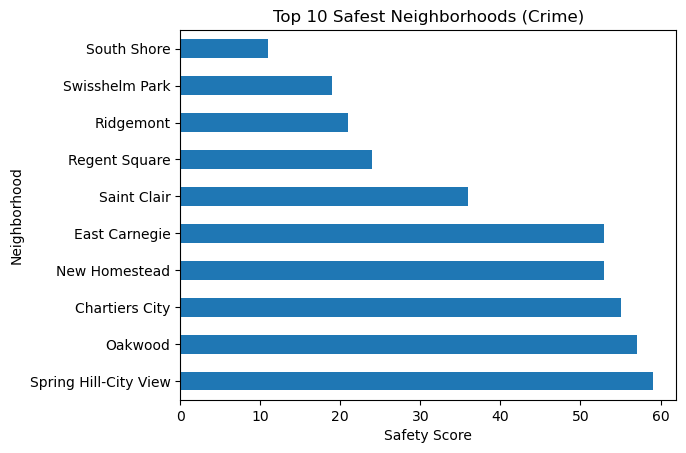

In [143]:
import matplotlib.pyplot as plt

top10_crime = neighborhood_scores_crime.head(10).reset_index()
top10_crime.columns = ["Neighborhood_Cleaned", "Safety Score"]

top10_crime

top10_crime.plot(kind="barh", x="Neighborhood_Cleaned", y="Safety Score", legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 Safest Neighborhoods (Crime)")
plt.xlabel("Safety Score")
plt.ylabel("Neighborhood")
plt.show()

Visualize which neighborhood is the safest from columns

In [144]:
import requests
import geopandas as gpd
from io import BytesIO

geo_url = "https://data.wprdc.org/dataset/e672f13d-71c4-4a66-8f38-710e75ed80a4/resource/4af8e160-57e9-4ebf-a501-76ca1b42fc99/download/neighborhoods.geojson"

response = requests.get(geo_url)

with open("neighborhoods.geojson", "wb") as f:
    f.write(response.content)

neighborhoods = gpd.read_file("neighborhoods.geojson")

In [145]:
neighborhoods.columns

Index(['OBJECTID', 'fid_blockg', 'statefp10', 'countyfp10', 'tractce10',
       'blkgrpce10', 'geoid10', 'namelsad10', 'mtfcc10', 'funcstat10',
       'aland10', 'awater10', 'intptlat10', 'intptlon10', 'shape_leng',
       'fid_neighb', 'perimeter', 'neighbor_', 'neighbor_i', 'hood', 'hood_no',
       'acres', 'sqmiles', 'dpwdiv', 'unique_id', 'sectors', 'shape_le_1',
       'shape_ar_1', 'page_number', 'plannerassign', 'created_user',
       'created_date', 'last_edited_user', 'last_edited_date', 'temp',
       'pghdb_sde_Neighborhood_2010_are', 'GlobalID', 'Shape__Area',
       'Shape__Length', 'geometry'],
      dtype='object')

In [146]:
df["weight"] = df["NIBRS_Offense_Category"].apply(get_weight)

In [147]:
crime_scores = df.groupby("Neighborhood")["weight"].sum().reset_index()

In [148]:
crime_scores.columns = ["Neighborhood", "crime_score"]

In [149]:
neighborhoods.head()

,OBJECTID,fid_blockg,statefp10,countyfp10,tractce10,blkgrpce10,geoid10,namelsad10,mtfcc10,funcstat10,...,created_user,created_date,last_edited_user,last_edited_date,temp,pghdb_sde_Neighborhood_2010_are,GlobalID,Shape__Area,Shape__Length,geometry
0,1,233,42,003,140500,3,420031405003,Block Group 3,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:13+00:00,None,7968760.0,a642a6b6-a2a9-48d5-acf2-3e2ce87d4bc0,8.417067e+06,14181.728584,"POLYGON ((-79.90531 40.45549, -79.90488 40.455..."
1,2,203,42,003,140100,3,420031401003,Block Group 3,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:41+00:00,None,34078712.0,20d4605b-258e-441a-a57e-a28fdabb6d30,3.410837e+07,30326.819418,"POLYGON ((-79.92063 40.44423, -79.92052 40.443..."
2,3,86,42,003,101700,2,420031017002,Block Group 2,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 12:59:55+00:00,None,12751163.0,bf4065e7-c29c-48bd-b529-e7fd99077238,1.275115e+07,14577.426328,"POLYGON ((-79.93546 40.47257, -79.9353 40.4725..."
3,4,214,42,003,050900,1,420030509001,Block Group 1,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 12:58:41+00:00,None,4997335.5,fed3fb32-0cd3-4556-aa41-17ee03b4fe41,4.897519e+06,13941.514356,"POLYGON ((-79.96601 40.4552, -79.96595 40.4548..."
4,5,173,42,003,300100,5,420033001005,Block Group 5,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:00:19+00:00,None,8411048.0,8669d2f0-b886-4519-99d0-bb1015b592b0,8.353046e+06,12021.860516,"POLYGON ((-79.98819 40.41852, -79.98824 40.418..."


In [150]:
crime_scores = df.groupby("Neighborhood_Cleaned")["weight"].sum().reset_index()

In [151]:
map_data = neighborhoods.merge(
    crime_scores,
    left_on="hood",
    right_on="Neighborhood_Cleaned",
    how="left"
)

In [152]:
neighborhood_scores = df.groupby("Neighborhood_Cleaned")["weight"].sum().sort_values()

In [153]:
neighborhood_scores.reset_index().columns

Index(['Neighborhood_Cleaned', 'weight'], dtype='object')

In [154]:
map_data.columns

Index(['OBJECTID', 'fid_blockg', 'statefp10', 'countyfp10', 'tractce10',
       'blkgrpce10', 'geoid10', 'namelsad10', 'mtfcc10', 'funcstat10',
       'aland10', 'awater10', 'intptlat10', 'intptlon10', 'shape_leng',
       'fid_neighb', 'perimeter', 'neighbor_', 'neighbor_i', 'hood', 'hood_no',
       'acres', 'sqmiles', 'dpwdiv', 'unique_id', 'sectors', 'shape_le_1',
       'shape_ar_1', 'page_number', 'plannerassign', 'created_user',
       'created_date', 'last_edited_user', 'last_edited_date', 'temp',
       'pghdb_sde_Neighborhood_2010_are', 'GlobalID', 'Shape__Area',
       'Shape__Length', 'geometry', 'Neighborhood_Cleaned', 'weight'],
      dtype='object')

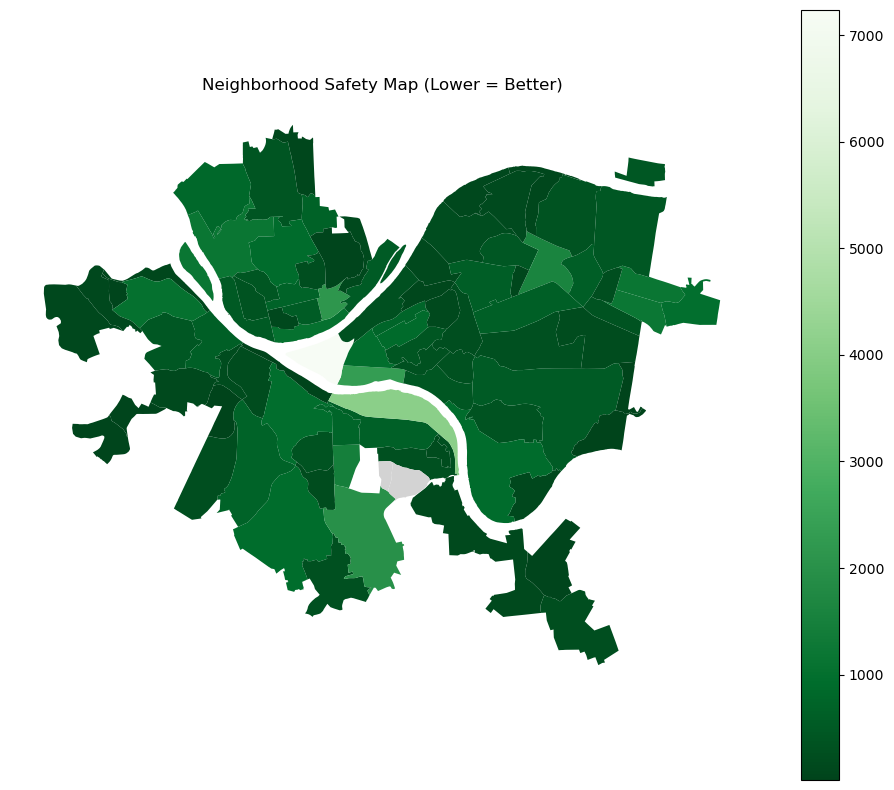

In [155]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

map_data.plot(
    column="weight", 
    cmap="Greens_r",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

plt.title("Neighborhood Safety Map (Lower = Better)")
plt.axis("off")
plt.show()

In [156]:
map_data.columns

Index(['OBJECTID', 'fid_blockg', 'statefp10', 'countyfp10', 'tractce10',
       'blkgrpce10', 'geoid10', 'namelsad10', 'mtfcc10', 'funcstat10',
       'aland10', 'awater10', 'intptlat10', 'intptlon10', 'shape_leng',
       'fid_neighb', 'perimeter', 'neighbor_', 'neighbor_i', 'hood', 'hood_no',
       'acres', 'sqmiles', 'dpwdiv', 'unique_id', 'sectors', 'shape_le_1',
       'shape_ar_1', 'page_number', 'plannerassign', 'created_user',
       'created_date', 'last_edited_user', 'last_edited_date', 'temp',
       'pghdb_sde_Neighborhood_2010_are', 'GlobalID', 'Shape__Area',
       'Shape__Length', 'geometry', 'Neighborhood_Cleaned', 'weight'],
      dtype='object')

Saftey score is now attached to a map given from previous data in this metric. In conclusion, Chartiers city seems to be the safest neigborhood within crime in our metric according to arrest reports.

# Metric #2: Housing Violations reports

***By Matthew***

In [157]:
from IPython.display import Image, display

url = "https://ap.rdcpix.com/bc8d1681e0a6b43ee43815fbcda0772cl-m740192753od-w480_h360_x2.jpg"

display(Image(url=url))

This sub-metric shows the condition of buildings, infrastructure, and environmental maintenance by the numbers of PLI/ES/DOMI Violations per neighborhood. \
PLI: Permits, Licenses & Inspections \
DOMI: Department of Mobility & Infrastructure \
ES: Environmental Services

In [159]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.wprdc.org/datastore/dump/70c06278-92c5-4040-ab28-17671866f81c"
df = pd.read_csv(url)

df.head()

,_id,casefile_number,address,parcel_id,status,case_file_type,investigation_date,investigation_outcome,investigation_findings,violation_description,...,violation_spec_instructions,court_date,court_time,docket_number,court_decision,latitude,longitude,neighborhood,ward,council_district
0,11451991,CF-PLI-2022-025648,"4314 MCCASLIN ST, Pittsburgh, PA 15217-",0055G00220000000,Closed,Weeds/Debris,2022-07-15,No Violation Found,no evidence of box debris on property at time ...,NaN,...,NaN,NaN,NaN,NaN,NaN,40.420940,-79.937538,Greenfield,15.0,5.0
1,11451992,CF-PLI-2022-046158,"2126 CROSBY AVE, Pittsburgh, PA 15216-",0035N00192000000,Closed,Building Without a Permit,2022-11-29,No Violation Found,Upon investigation the retaining wall in quest...,NaN,...,NaN,NaN,NaN,NaN,NaN,40.405125,-80.030487,Beechview,19.0,4.0
2,11451993,CF-DOMI-2025-050525,"2126 CROSBY AVE, Pittsburgh, PA 15216-",0035N00192000000,Closed,Utility Poles and Wires,2025-09-18,No Violation Found,"At the time of inspection, Wire Removed",NaN,...,NaN,NaN,NaN,NaN,NaN,40.405125,-80.030487,Beechview,19.0,4.0
3,11451994,CF-PLI-2022-004504,"5808 HOBART ST, Pittsburgh, PA 15217-",0086R00190000000,Closed,Building Without a Permit,2022-02-25,No Violation Found,no apparent work being completed from exterior...,NaN,...,NaN,NaN,NaN,NaN,NaN,40.433543,-79.922388,Squirrel Hill South,14.0,5.0
4,11451995,CF-PLI-2020-009190,"1 LECKY AVE, Pittsburgh, PA 15212-",0075S00169000000,Closed,Weeds/Debris,2020-07-23,No Violation Found,No violation property next door was demoed and...,NaN,...,NaN,NaN,NaN,NaN,NaN,40.472308,-80.036201,Marshall-Shadeland,27.0,6.0


In [160]:
df["violation_score"] = 1

In [161]:
neighborhood_scores_pli = df.groupby("neighborhood")["violation_score"].sum().sort_values()

In [162]:
df["violation_score"] = 1

neighborhood_scores = df.groupby("neighborhood")["violation_score"].sum().sort_values()

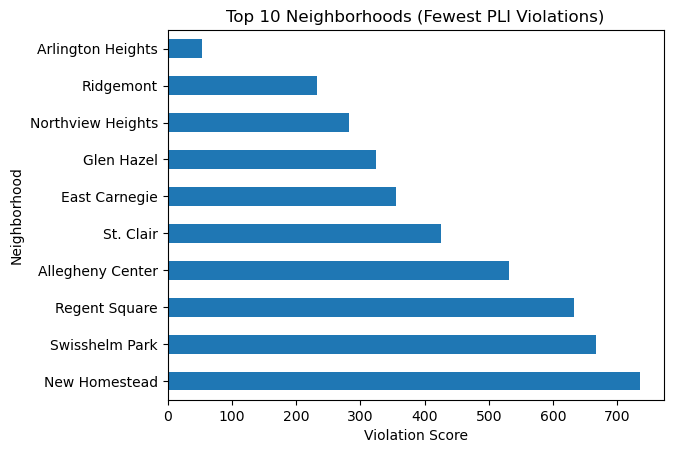

In [163]:
top10_pli = neighborhood_scores_pli.head(10).reset_index()
top10_pli.columns = ["Neighborhood", "Violation Score"]

top10_pli  # optional display

top10_pli.plot(kind="barh", x="Neighborhood", y="Violation Score", legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 Neighborhoods (Fewest PLI Violations)")
plt.xlabel("Violation Score")
plt.ylabel("Neighborhood")
plt.show()

Clean dataset of of violations for visualization up above

In [164]:
top10 = neighborhood_scores_pli.head(10).reset_index()
top10.columns = ["Neighborhood", "Violation Score"]

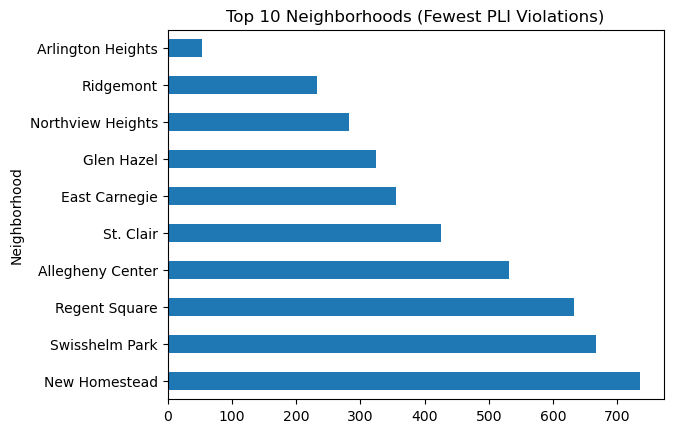

In [165]:
import matplotlib.pyplot as plt

top10.plot(
    kind="barh",
    x="Neighborhood",
    y="Violation Score",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Top 10 Neighborhoods (Fewest PLI Violations)")
plt.show()

Visually shows which neighborhood has fewest violations. Arlington Heights has fewest violations in the chart according to the data we were given.

### Matthew's Conlusion (By Arrest and Violations metrics)

***Personally, I believe Ridgemont is the safest neighborhood in Pittsburgh. Though it didn't come first in any of my metrics, It still ranked high in both of them. A quick side not, although it isn't what I was looking for, it occured to me that New Homestead seems to be one of the worst neighborhoods according to my data. I've also done work outside of the classroom, and my friend from Pittsburgh says it isn't a safe neighborhood. P.S, sorry to anyone from New Homestead***

# Metric #3: Condemned and Dead-end Properties

***By Arif***

In [166]:
from IPython.display import Image, display

url = "https://www.rismedia.com/wp-content/uploads/2022/07/condemed_house-iStock-1139484240-750x499.jpg"

display(Image(url=url))

In [167]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.wprdc.org/datastore/dump/0a963f26-eb4b-4325-bbbc-3ddf6a871410"
cpfile = pd.read_csv(url)

In [168]:
cpfile.columns

Index(['_id', 'parcel_id', 'address', 'zip_code', 'owner', 'property_type',
       'create_date', 'latest_inspection_result', 'latest_inspection_score',
       'record_number', 'inspection_status', 'latitude', 'longitude',
       'neighborhood', 'council_district', 'ward'],
      dtype='object')

In [169]:
latest_records = cpfile.sort_values(by=['parcel_id', 'create_date'], ascending=[True, False]).drop_duplicates(subset=['parcel_id'])
non_pass_properties = latest_records[latest_records['latest_inspection_result'] != 'Pass']

unique_properties = non_pass_properties.drop_duplicates(subset=['parcel_id'])
neighborhood_stats = unique_properties['neighborhood'].value_counts().sort_values()

safest = neighborhood_stats[neighborhood_stats == neighborhood_stats.min()]

Finding the unique properties not to count the same properties more than once. Then sorting the neighborhoods by the number of condemned properties.

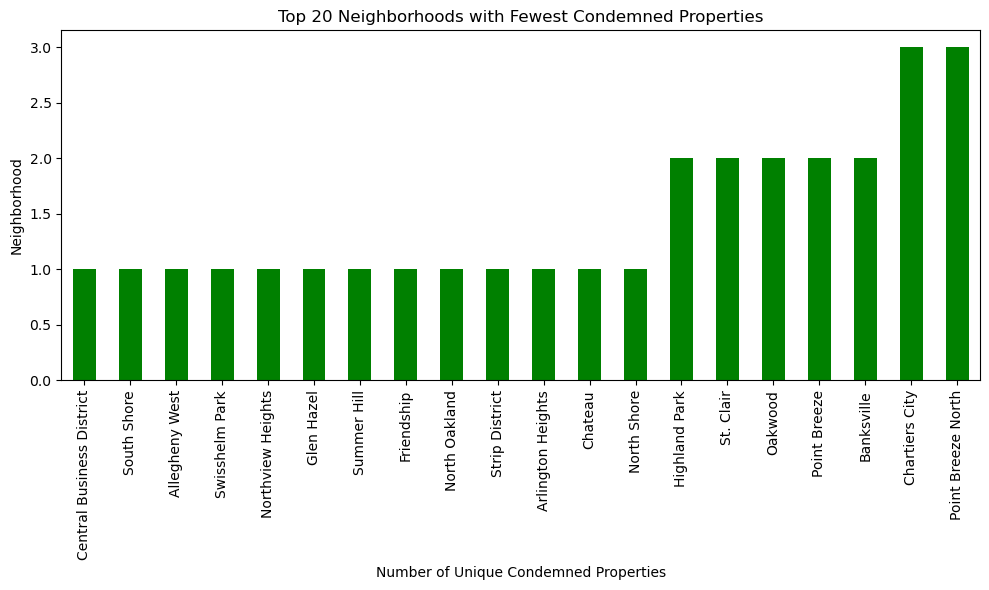

In [170]:
plt.figure(figsize=(10, 6))
neighborhood_stats.head(20).plot(kind='bar', color='green')
plt.title('Top 20 Neighborhoods with Fewest Condemned Properties')
plt.xlabel('Number of Unique Condemned Properties')
plt.ylabel('Neighborhood')
plt.tight_layout()

20 Neighborhoods with the least condemned properties

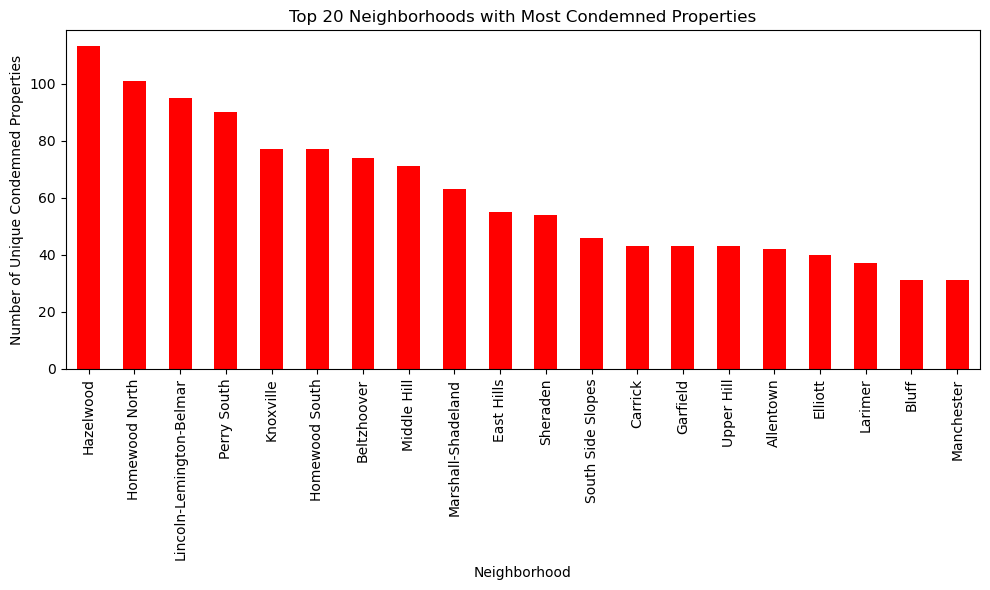

In [171]:
most_condemned = unique_properties['neighborhood'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
most_condemned.head(20).plot(kind='bar', color='red')
plt.title('Top 20 Neighborhoods with Most Condemned Properties')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Unique Condemned Properties')
plt.tight_layout()

20 Neighborhoods with the most condemned properties

### Arif's Conlusion (By Condemned Properties metrics)

***From the metric that I analyzed, it is not quite possible to tell which neighborhood is the best because there ten different neighborhoods with only single condemned properties. So, I don’t have a single “best.” Here are the “bests:” South Shore, Chateau, Central Business District, North Oakland, Glen Hazel, Summer Hill, Swisshelm Park, Strip District, Arlington Heights, Friendship, Allegheny West***

# Overall Conclusion(Overall best neighborhood in Pittsburgh by all metrics)

Overall Winner: ***Saint Clair*** with 2 Condemned Properties, a Safety Score weighted from arrests of 35, and a score of a little over 400 for PLI/DOMI/ES Violations